# Assignment 1 - Grayscale to binary

> Write a program to convert a grayscale image to a binary image.
> - **Case 1:** Assume mean intensity of the image as the threshold value
> - **Case 2:** Input the threshold value from the user

### What you actually learn here
- an image is a `numpy` array of `uint8`, nothing more
- a comparison on an array produces a **boolean mask** - the single most useful object in CV
- why `bool` must become `0/255` before you can save or display it
- how to read a histogram and predict what a threshold will do *before* running it

gray: shape=(512, 512)  dtype=uint8  min=18  max=248
mean intensity: 124.20059967041016


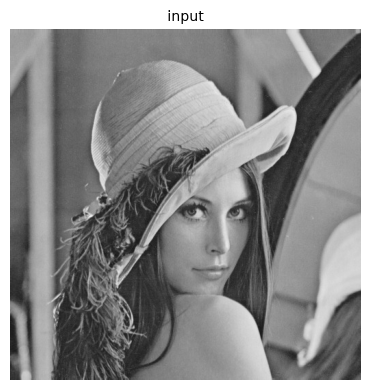

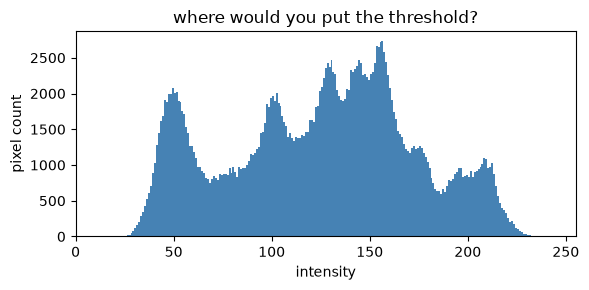

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
# the graders are the test harness -- everything else is written out in full
from cvlab import check_binary_fixed, check_binary_mean

gray = cv2.imread("images/lena.jpg", cv2.IMREAD_GRAYSCALE)
print(f"gray: shape={gray.shape}  dtype={gray.dtype}  min={gray.min()}  max={gray.max()}")
print("mean intensity:", gray.mean())
_imgs, _titles = [gray], ["input"]
fig, axes = plt.subplots(1, 1, figsize=(4 * 1, 4), squeeze=False)
for ax, im, t in zip(axes.ravel(), _imgs, _titles):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255) if im.ndim == 2 else ax.imshow(im)
    ax.set_title(t, fontsize=10); ax.axis("off")
for ax in axes.ravel()[len(_imgs):]: ax.axis("off")
plt.tight_layout(); plt.show()
plt.figure(figsize=(6, 3))
plt.hist(gray.ravel(), bins=256, range=(0, 256), color="steelblue")
plt.title("where would you put the threshold?"); plt.xlabel("intensity"); plt.ylabel("pixel count")
plt.xlim(0, 255); plt.tight_layout(); plt.show()

In [3]:
fotu = cv2.imread("images/baboon.jpg")
fotu
print("before conversion to gray")
print("height:",fotu.shape[0])
print("width:",fotu.shape[1])
print("channels:",fotu.shape[2])

print("after conversion to gray:")
gray = cv2.cvtColor(fotu,cv2.COLOR_BGR2GRAY)
print("height:",gray.shape[0])
print("width:",gray.shape[1])
# cv2.imshow("fotu",fotu)
# cv2.imshow("gray",gray)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

## prints nothing because only one channel hence 512x512


before conversion to gray
height: 512
width: 512
channels: 3
after conversion to gray:
height: 512
width: 512


In [ ]:
import cv2

img = cv2.imread("images/baboon.jpg")

print("Shape:", img.shape)
print("First pixel:", img[0, 0])

B = img[:, :, 0]
G = img[:, :, 1]
R = img[:, :, 2]

print("Blue channel shape:", B.shape)
print("Green channel shape:", G.shape)
print("Red channel shape:", R.shape)

# cv2.imshow + cv2.waitKey need a native window loop a Jupyter kernel doesn't have --
# waitKey(0) just blocks forever with no error. Use matplotlib in a notebook instead:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, ch, name in zip(axes, [B, G, R], ["Blue", "Green", "Red"]):
    ax.imshow(ch, cmap="gray", vmin=0, vmax=255)
    ax.set_title(name); ax.axis("off")
plt.tight_layout(); plt.show()

---
## First: reading and writing images, and the BGR trap

Before any processing, the two functions you will type more than any others:

```python
img = cv2.imread(filename, flags)      # returns a numpy array, or None
ok  = cv2.imwrite(filename, img)       # returns True/False; format from the extension
```

**Three things about `imread` that catch everyone:**

1. **It returns BGR, not RGB.** OpenCV predates the convention everyone else settled on.
   A "blue" image displayed with matplotlib means you forgot to convert. This is the most
   common OpenCV bug in existence.
2. **It returns `None` on failure — it does not raise.** A typo in the path gives you `None`,
   and you find out one line later with
   `TypeError: Expected Ptr<cv::UMat> for argument 'src'`. Always check.
3. **The flag changes the array's shape**, not just its content:

| flag | value | result |
|---|---|---|
| `cv2.IMREAD_COLOR` | 1 | `(H, W, 3)` **BGR**, drops any alpha channel — the default |
| `cv2.IMREAD_GRAYSCALE` | 0 | `(H, W)`, converted using the luma weights |
| `cv2.IMREAD_UNCHANGED` | -1 | as stored, **keeps alpha** → `(H, W, 4)` for a transparent PNG |

You can pass the bare integers `1`, `0`, `-1` and a lot of code does, which is why you should
recognise them.

**Displaying:** `cv2.imshow` opens a real OS window and needs `cv2.waitKey`, so it does not
work in a notebook — it is for scripts (there is one in notebook 00). In a notebook you use
matplotlib, which expects **RGB**:

```python
plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))   # colour
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)    # grayscale -- pass vmin/vmax or
                                                   # matplotlib auto-scales and lies to you
```

`show(...)` in these notebooks is a thin wrapper around exactly those two lines — it is a
**plotting** shortcut only, and hides no OpenCV. Read it in `cvlab.py` if you want.

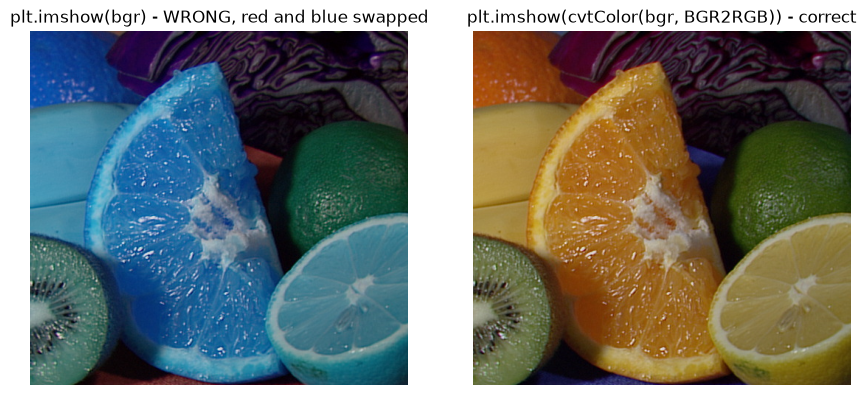

a red pixel in BGR order: [ 50 107 158]  -> in RGB order: [158 107  50]
IMREAD_COLOR   (1)       shape=(480, 512, 3)    dtype=uint8
IMREAD_GRAYSCALE (0)     shape=(480, 512)       dtype=uint8
IMREAD_UNCHANGED (-1)    shape=(480, 512, 3)    dtype=uint8
\nimread on a bad path returns: None   <- not an exception!
read_or_die works: (512, 512, 3)
\nimwrite returned True;  png 428,398 bytes  vs jpg q50 24,411 bytes
NOTE: imwrite expects BGR. Passing RGB writes a colour-swapped file -- silently.


[ WARN:0@62.359] global loadsave.cpp:268 findDecoder imread_('images/does_not_exist.jpg'): can't open/read file: check file path/integrity


In [4]:
import cv2, numpy as np, matplotlib.pyplot as plt

# 1. The BGR trap, made visible. Same file, same bytes, two interpretations.
bgr = cv2.imread("images/fruits.jpg")             # <- what OpenCV actually gives you
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)        # <- what matplotlib expects
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(bgr); ax[0].set_title("plt.imshow(bgr) - WRONG, red and blue swapped")
ax[1].imshow(rgb); ax[1].set_title("plt.imshow(cvtColor(bgr, BGR2RGB)) - correct")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
print("a red pixel in BGR order:", bgr[60, 200], " -> in RGB order:", rgb[60, 200])

# 2. The flags change the SHAPE.
for flag, name in [(cv2.IMREAD_COLOR, "IMREAD_COLOR   (1)"),
                   (cv2.IMREAD_GRAYSCALE, "IMREAD_GRAYSCALE (0)"),
                   (cv2.IMREAD_UNCHANGED, "IMREAD_UNCHANGED (-1)")]:
    im = cv2.imread("images/fruits.jpg", flag)
    print(f"{name:24} shape={str(im.shape):16} dtype={im.dtype}")

# 3. Failure is silent. THIS is why you check.
missing = cv2.imread("images/does_not_exist.jpg")
print("\\nimread on a bad path returns:", missing, "  <- not an exception!")
assert missing is None
# the habit to build:
def read_or_die(path, flag=cv2.IMREAD_COLOR):
    img = cv2.imread(path, flag)
    if img is None:
        raise FileNotFoundError(path)
    return img
print("read_or_die works:", read_or_die("images/lena.jpg").shape)

# 4. Writing. Extension picks the format; quality is optional per-format.
ok = cv2.imwrite("/tmp/out.png", bgr)
cv2.imwrite("/tmp/out_q50.jpg", bgr, [cv2.IMWRITE_JPEG_QUALITY, 50])
import os
print(f"\\nimwrite returned {ok};  png {os.path.getsize('/tmp/out.png'):,} bytes"
      f"  vs jpg q50 {os.path.getsize('/tmp/out_q50.jpg'):,} bytes")
print("NOTE: imwrite expects BGR. Passing RGB writes a colour-swapped file -- silently.")

## The one idea

```python
mask = gray > 120      # -> array of True/False, same shape, dtype=bool
```

`mask` is not an image yet. `True`/`False` display and save badly. Multiply by 255 and cast:

```python
binary = (mask * 255).astype(np.uint8)
```

Two traps that will bite you:

1. **`uint8` wraps around.** `np.uint8(250) + 10` is `4`, not `260`. Any arithmetic that can
   leave `[0,255]` must happen in a wider type, then be cast back.
2. **`.astype(np.uint8)` truncates, it does not round.** `np.float64(127.9).astype(np.uint8)` is `127`.
   Use `.round()` first when you mean rounding.

In [5]:
# See both traps for yourself. Predict each line's output before running.
print(np.uint8(250) + np.uint8(10))
print(np.array([127.9, 128.5]).astype(np.uint8))
print(np.array([127.9, 128.5]).round().astype(np.uint8))
print((np.array([True, False]) * 255).astype(np.uint8))

4
[127 128]
[128 128]
[255   0]


/var/folders/y3/nq41wqsn6877qhrzs07ytt2w0000gn/T/ipykernel_62578/3781944752.py:2: RuntimeWarning: overflow encountered in scalar add
  print(np.uint8(250) + np.uint8(10))


---
## Task 1 - threshold supplied by the user

Fill in `my_threshold`. Convention the grader uses: a pixel is **white when it is strictly
greater than `t`**, black otherwise.

In [12]:
def my_threshold(gray, t):
    """Threshold a grayscale image at t.

    Parameters
    ----------
    gray : (H, W) uint8 array
    t    : int, 0..255

    Returns
    -------
    (H, W) uint8 array containing only 0 and 255.
    Pixels with value > t become 255; all others become 0.
    """
    # TODO: your code here (one or two lines is enough)
    output = gray.copy()

    for i in range(gray.shape[0]):
        for j in range(gray.shape[1]):
            if gray[i][j]>t :
                output[i][j]=255
            else:
                output[i][j]=0
    return output

    raise NotImplementedError

In [13]:
check_binary_fixed(my_threshold)

  PASS  output is uint8
  PASS  output shape == input shape
  PASS  only 0 and 255 appear
  PASS  pixels above t are 255
  PASS  pixels at or below t are 0
  PASS  t=0 keeps only intensity 0 black
  PASS  t=255 gives an all-black image
  PASS  matches cv2.threshold on lena at t=90

All checks passed for binary_fixed. Nice.


In [14]:
# ---- The real OpenCV call ----------------------------------------------------
# cv2.threshold(src, thresh, maxval, type) -> (retval, dst)      <- returns a TUPLE
# The [1] to grab the image is the #1 thing people forget in an exam.
import cv2, numpy as np
retval, cv_out = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)
print("retval (the threshold it used):", retval)
assert np.array_equal(cv_out, my_threshold(gray, 120)), "your version disagrees with cv2"
print("match. Other `type` values worth knowing:")
print("  THRESH_BINARY_INV, THRESH_TRUNC, THRESH_TOZERO, THRESH_TOZERO_INV")
print("  + cv2.THRESH_OTSU / + cv2.THRESH_TRIANGLE  (pass thresh=0, read it back from retval)")

retval (the threshold it used): 120.0
match. Other `type` values worth knowing:
  THRESH_BINARY_INV, THRESH_TRUNC, THRESH_TOZERO, THRESH_TOZERO_INV
  + cv2.THRESH_OTSU / + cv2.THRESH_TRIANGLE  (pass thresh=0, read it back from retval)


<details>
<summary><b>Nudge (open only after you have tried)</b></summary>

You need exactly two ingredients: a comparison against `t`, and a conversion from
boolean to `uint8` in the 0/255 range. Both appear in the cell titled *The one idea*.

</details>

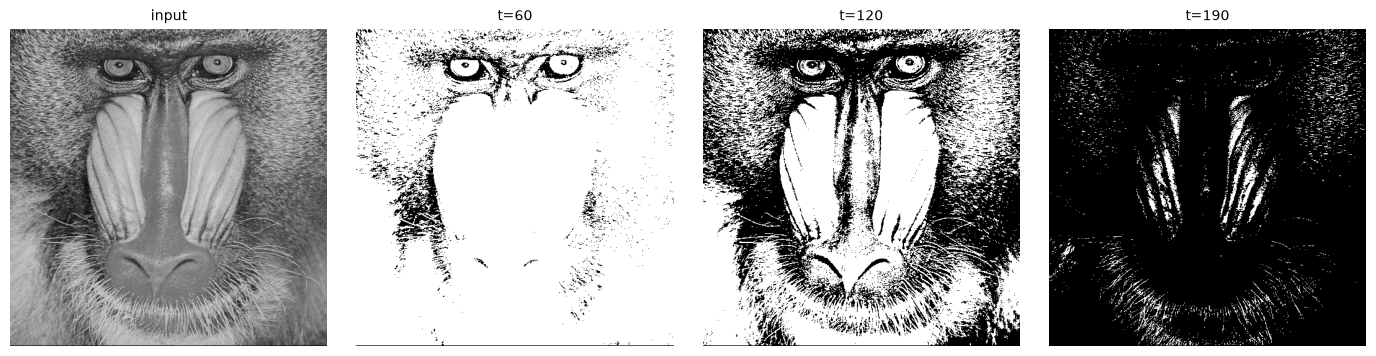

In [15]:
_imgs, _titles = [gray, my_threshold(gray, 60), my_threshold(gray, 120), my_threshold(gray, 190)], ["input", "t=60", "t=120", "t=190"]
fig, axes = plt.subplots(1, 4, figsize=(3.5 * 4, 3.5), squeeze=False)
for ax, im, t in zip(axes.ravel(), _imgs, _titles):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255) if im.ndim == 2 else ax.imshow(im)
    ax.set_title(t, fontsize=10); ax.axis("off")
for ax in axes.ravel()[len(_imgs):]: ax.axis("off")
plt.tight_layout(); plt.show()

---
## Task 2 - threshold chosen automatically from the mean

Same output format, but the threshold is the image's own mean intensity. Note that the mean
is a **float** (lena's is about 124.05) - do not round it to an int first, the grader tests
a ramp image whose mean is exactly 127.5 and it checks that 127 goes black while 128 goes white.

In [ ]:
def my_threshold_mean(gray):
    """Threshold a grayscale image at its own mean intensity.

    Parameters
    ----------
    gray : (H, W) uint8 array

    Returns
    -------
    (H, W) uint8 array of 0 and 255, white where the pixel exceeds the image mean.
    """
    # TODO: your code here
    raise NotImplementedError

In [ ]:
check_binary_mean(my_threshold_mean)

In [ ]:
# ---- The real OpenCV call ----------------------------------------------------
import cv2, numpy as np
_, cv_out = cv2.threshold(gray, gray.mean(), 255, cv2.THRESH_BINARY)
assert np.array_equal(cv_out, my_threshold_mean(gray)), "your version disagrees with cv2"
# Otsu picks the threshold FOR you -- pass 0 and read it back from retval:
t_otsu, otsu_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"mean threshold = {gray.mean():.1f}   Otsu threshold = {t_otsu:.0f}")
# And adaptive thresholding, for uneven lighting:
# cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)
ad = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
_imgs, _titles = [my_threshold_mean(gray), otsu_img, ad], ["yours (mean)", "cv2 Otsu", "cv2 adaptive"]
fig, axes = plt.subplots(1, 3, figsize=(3.5 * 3, 3.5), squeeze=False)
for ax, im, t in zip(axes.ravel(), _imgs, _titles):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255) if im.ndim == 2 else ax.imshow(im)
    ax.set_title(t, fontsize=10); ax.axis("off")
for ax in axes.ravel()[len(_imgs):]: ax.axis("off")
plt.tight_layout(); plt.show()

<details>
<summary><b>Nudge (open only after you have tried)</b></summary>

Reuse Task 1. `my_threshold_mean` should be a single line that calls `my_threshold`.
The array method you want is `.mean()`.

</details>

In [ ]:
import cv2
for name in ["lena.jpg", "baboon.jpg", "sudoku.png", "board.jpg"]:
    g = cv2.imread(f"images/{name}", cv2.IMREAD_GRAYSCALE)
    _imgs, _titles = [g, my_threshold_mean(g)], [name, f"mean threshold = {g.mean():.1f}"]
    fig, axes = plt.subplots(1, 2, figsize=(3.5 * 2, 3.5), squeeze=False)
    for ax, im, t in zip(axes.ravel(), _imgs, _titles):
        ax.imshow(im, cmap="gray", vmin=0, vmax=255) if im.ndim == 2 else ax.imshow(im)
        ax.set_title(t, fontsize=10); ax.axis("off")
    for ax in axes.ravel()[len(_imgs):]: ax.axis("off")
    plt.tight_layout(); plt.show()

---
## Think about it

Write your answers as comments or in a markdown cell. These are the parts an examiner asks about.

1. Look at the `sudoku.png` result above. The mean threshold destroys part of the grid.
   Read its histogram (`hist(load("sudoku.png", gray=True))`) and explain *from the histogram*
   why a single global threshold cannot work for that image.
2. For which shape of histogram is the mean a *good* threshold?
3. `my_threshold(gray, 255)` returns an all-black image. Is `my_threshold(gray, 0)` all-white? Why not?
4. What happens to the count of white pixels as `t` goes 0 -> 255? Is it monotonic? Prove it in one line of code.

In [ ]:
# Scratch space for question 4.

---
## Stretch (do these if you want the marks and the understanding)

1. **Otsu.** `cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)` picks the threshold
   that minimises within-class variance. Compare it against your mean threshold on all four images.
   Print both numbers. On which image do they differ most, and why?
2. **Adaptive thresholding** fixes `sudoku.png`. Try
   `cv2.adaptiveThreshold(g, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)`
   and explain in one sentence what "adaptive" is doing differently.
3. **Implement Otsu yourself** from the 256-bin histogram. This is a genuinely good exercise:
   for every candidate `t`, compute the two class weights and means, maximise the between-class
   variance. About 10 lines with numpy, no loops needed over pixels.

In [ ]:
# Stretch scratch space.

---
## OpenCV API card - image I/O and thresholding

```python
img = cv2.imread(filename, flags=cv2.IMREAD_COLOR)   # -> BGR array, or None on failure
ok  = cv2.imwrite(filename, img, params=None)        # expects BGR; format from extension
```
`flags`: `IMREAD_COLOR` (1) → `(H,W,3)` BGR · `IMREAD_GRAYSCALE` (0) → `(H,W)` ·
`IMREAD_UNCHANGED` (-1) → keeps alpha.
`params` example: `[cv2.IMWRITE_JPEG_QUALITY, 90]` or `[cv2.IMWRITE_PNG_COMPRESSION, 9]`.

```python
cv2.imshow(winname, img); cv2.waitKey(0); cv2.destroyAllWindows()   # scripts only, not notebooks
img = cv2.imdecode(np.frombuffer(bytes_, np.uint8), flags)          # from memory, e.g. a download
ok, buf = cv2.imencode(".jpg", img)                                 # to memory
cap = cv2.VideoCapture(0 or "file.mp4"); ok, frame = cap.read(); cap.release()
```

`imread` **returns `None` rather than raising** — check it, or you get a confusing
`TypeError` about `Ptr<cv::UMat>` on the next line.

### Thresholding

Memorise the signatures, not just the names. `dst` is always the **return value**, never an
out-parameter you pass in.

```python
retval, dst = cv2.threshold(src, thresh, maxval, type)
```
| arg | meaning |
|---|---|
| `src` | 8-bit or 32F, **single channel** for Otsu |
| `thresh` | the threshold; pass `0` when combining with `THRESH_OTSU` |
| `maxval` | value written where the test passes (usually `255`) |
| `type` | `THRESH_BINARY`, `THRESH_BINARY_INV`, `THRESH_TRUNC`, `THRESH_TOZERO`, `THRESH_TOZERO_INV` |
| | `+ cv2.THRESH_OTSU` or `+ cv2.THRESH_TRIANGLE` to auto-pick, then read `retval` |

```python
dst = cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)
```
`adaptiveMethod` is `ADAPTIVE_THRESH_MEAN_C` or `ADAPTIVE_THRESH_GAUSSIAN_C`;
`blockSize` must be **odd**; `C` is subtracted from the local mean.
`thresholdType` here may only be `THRESH_BINARY` or `THRESH_BINARY_INV`.

```python
dst = cv2.inRange(src, lowerb, upperb)      # multi-channel thresholding -> 0/255 mask
```